# Importancia de características

En este notebook se hace uso de `feature_importances_` para analizar la importancia de cada variable explicativa para realizar las predicciones de la variable objetivo. Esto para cada uno de los modelos que estamos usando, `Random Forest`, `XGBoost`, `CatBoost` y `LightGBM`.

# Objetivo

Analizar la importancia de las variables explicativas en cada uno de los modelos por medio del atributo `feature_importances_`.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import joblib, json
import pandas as pd
import statics 
# Cargar datos
# Celda 2 — Carga de artefactos
ruta_base_data = "../data"

X_test = pd.read_parquet(f"{ruta_base_data}/X_test.parquet")
y_test = pd.read_parquet(f"{ruta_base_data}/y_test.parquet").squeeze()

models = {
    "Random Forest": joblib.load(f"{ruta_base_data}/models/rf_best.pkl"),
    "XGBoost":       joblib.load(f"{ruta_base_data}/models/xgb_best.pkl"),
    "CatBoost":      joblib.load(f"{ruta_base_data}/models/cb_best.pkl"),
    "LightGBM":      joblib.load(f"{ruta_base_data}/models/lgbm_best.pkl"),
}


df_importances =pd.DataFrame({
    'Feature':  X_test.columns
})
for name, model in models.items():
    df_importances[name]=model.named_steps['clf'].feature_importances_
# Obtener importancia de variables
        
    
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")
print(f"Modelos cargados: {list(models.keys())}")
# Normalizamos para los valores de CatBoost y LightGMB
df_importances['CatBoost'] = df_importances['CatBoost']/df_importances['CatBoost'].sum()
df_importances['LightGBM'] = df_importances['LightGBM']/df_importances['LightGBM'].sum()

# Mostrar resultados en tabla

df_importances

X_test: (1409, 19) | y_test: (1409,)
Modelos cargados: ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']


,Feature,Random Forest,XGBoost,CatBoost,LightGBM
0,gender,0.140817,0.032798,0.182893,0.176893
1,SeniorCitizen,0.095410,0.020229,0.090211,0.295381
2,Partner,0.091649,0.021502,0.106726,0.266179
3,Dependents,0.003938,0.012839,0.016447,0.004296
4,tenure,0.005466,0.012792,0.008686,0.007250
5,PhoneService,0.005081,0.007629,0.002732,0.013225
6,MultipleLines,0.006403,0.016765,0.008082,0.010271
7,InternetService,0.002947,0.019671,0.000555,0.005169
8,OnlineSecurity,0.016661,0.027830,0.018972,0.017320
9,OnlineBackup,0.007909,0.014208,0.028333,0.021079


In [74]:
df_importances.rank(ascending=False)
df_importances.drop('Feature',axis=1).corr(method='spearman')

,Random Forest,XGBoost,CatBoost,LightGBM
Random Forest,1.000000,0.724561,0.868421,0.761404
XGBoost,0.724561,1.000000,0.647368,0.426316
CatBoost,0.868421,0.647368,1.000000,0.821053
LightGBM,0.761404,0.426316,0.821053,1.000000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Colores por modelo
colors = {
    'Random Forest': '#3266ad',
    'XGBoost':       '#1D9E75',
    'CatBoost':      '#D85A30',
    'LightGBM':      '#7F77DD'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, model_name in enumerate(['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']):
    ax = axes[idx]
    df_sorted = df_importances[['Feature', model_name]].sort_values(model_name, ascending=True)
    ax.barh(df_sorted['Feature'], df_sorted[model_name],
            color=colors[model_name], edgecolor='none', height=0.7)
    ax.set_title(model_name, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Importancia', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    # Etiquetas de valor
    for bar, val in zip(ax.patches, df_sorted[model_name]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=7.5,
                color='#555')

fig.suptitle('Importancia de variables por modelo', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: feature_importance_by_model.png')


In [ ]:
# Importancia global: promedio de los cuatro modelos
model_cols = ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']
df_global = df_importances.copy()
df_global['Global_Avg'] = df_global[model_cols].mean(axis=1)
df_global = df_global.sort_values('Global_Avg', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(df_global['Feature'], df_global['Global_Avg'],
               color='#5A7FC4', edgecolor='none', height=0.7, label='Promedio global')

# Puntos por modelo encima de las barras
dot_colors = {'Random Forest':'#3266ad','XGBoost':'#1D9E75','CatBoost':'#D85A30','LightGBM':'#7F77DD'}
markers = {'Random Forest':'o','XGBoost':'s','CatBoost':'^','LightGBM':'D'}
for model in model_cols:
    ax.scatter(df_global[model], df_global['Feature'],
               color=dot_colors[model], marker=markers[model],
               s=35, zorder=5, label=model, alpha=0.85)

ax.set_title('Importancia global promedio de variables\n(con distribución por modelo)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importancia', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', fontsize=9, framealpha=0.7)

# Etiquetas
for bar, val in zip(bars, df_global['Global_Avg']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig('feature_importance_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: feature_importance_global.png')


In [ ]:
import seaborn as sns

corr_matrix = df_importances.drop('Feature', axis=1).corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5.5))

mask = np.zeros_like(corr_matrix, dtype=bool)
# No mask — mostramos la matriz completa con anotaciones

cmap = sns.color_palette('YlGn', as_cmap=True)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap=cmap,
    vmin=0.4, vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Spearman'}
)

ax.set_title('Similitud entre modelos\n(Correlación de Spearman sobre rankings de importancia)',
             fontsize=12, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: spearman_heatmap.png')


# Conclusiones del análisis de Feature Importance

---

## 1. Variable más importante de forma global: `MonthlyCharges`

`MonthlyCharges` es la variable dominante para **Random Forest** (26.4%), **XGBoost** (32.3%) y **CatBoost** (24.2%), con márgenes amplios sobre el resto. Esto tiene sentido desde una perspectiva de negocio: el cargo mensual resume implícitamente el tipo de contrato, los servicios contratados y el perfil económico del cliente.

La excepción notable es **LightGBM**, que le asigna apenas un 2.5% de importancia. Esto no implica que la variable sea irrelevante, sino que LightGBM redistribuye el crédito de manera diferente, en parte por cómo calcula `feature_importances_` (frecuencia de splits vs. ganancia ponderada).

---

## 2. Variables demográficas: ignoradas por unos, centrales para otros

`gender`, `SeniorCitizen` y `Partner` son prácticamente irrelevantes para **XGBoost** (< 3% cada una), pero son las tres variables más importantes en **LightGBM**, donde acumulan más del **73%** de la importancia total. CatBoost y Random Forest les asignan entre un 30–40% combinado.

Esta discrepancia tan marcada en LightGBM merece atención: puede reflejar overfitting a patrones demográficos en el conjunto de entrenamiento, o que LightGBM explota splits en variables categóricas de baja cardinalidad de forma más agresiva. Se recomienda validar con **SHAP values** para distinguir si el efecto es real o un artefacto.

---

## 3. `TechSupport` y `Contract`: el segundo bloque relevante

Después de `MonthlyCharges`, las variables `TechSupport` y `Contract` son consistentemente importantes en RF, XGBoost y CatBoost. `Contract` es especialmente relevante para **XGBoost** (13.8%), lo que tiene lógica de negocio clara: el tipo de contrato (mensual vs. anual vs. dos años) es un predictor directo del riesgo de churn.

---

## 4. Variables con bajo poder predictivo en todos los modelos

Las variables `Dependents`, `tenure`, `PhoneService`, `InternetService` y `MultipleLines` aparecen consistentemente en las posiciones más bajas en los cuatro modelos. Son candidatas a eliminación si se desea reducir la dimensionalidad sin sacrificar rendimiento predictivo.

---

## 5. ¿Qué modelos piensan más parecido entre sí? (Correlación de Spearman)

La correlación de Spearman sobre los rankings de importancia revela una estructura clara:

| Par de modelos | ρ Spearman | Interpretación |
|---|---|---|
| RF ↔ CatBoost | **0.868** | Más similares — mismo criterio de importancia |
| CatBoost ↔ LightGBM | 0.821 | Alta similitud en rankings generales |
| RF ↔ LightGBM | 0.761 | Similitud moderada-alta |
| RF ↔ XGBoost | 0.725 | Similitud moderada |
| CatBoost ↔ XGBoost | 0.647 | Similitud moderada-baja |
| **XGBoost ↔ LightGBM** | **0.426** | **Más distintos** — visiones estructuralmente diferentes |

**RF y CatBoost** forman el par con mayor consenso, ambos priorizando `MonthlyCharges`, `gender`, `TechSupport` y `Partner`. **XGBoost y LightGBM** son los más divergentes a pesar de ser ambos variantes de gradient boosting: XGBoost concentra importancia en `MonthlyCharges` y `Contract`, mientras LightGBM la concentra en variables demográficas.

---

> **Recomendación:** Dado el consenso entre RF, XGBoost y CatBoost, las variables `MonthlyCharges`, `TechSupport` y `Contract` son las más robustas para un modelo de churn. El comportamiento atípico de LightGBM justifica una revisión con SHAP values antes de usar ese modelo en producción.


## *Explicación de predicciones con LIME*

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lime import lime_tabular
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
df = pd.read_csv("../data/telco_churn.csv")

df_clean = df.copy()
df_clean.drop(columns=["customerID"], inplace=True)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)

y = (df_clean.pop("Churn") == "Yes").astype(int)
X = df_clean

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")


Train: 5634 filas | Test: 1409 filas


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ruta_models = "../data/models"

models = {
    "Random Forest": joblib.load(f"{ruta_models}/rf_best.pkl"),
    "XGBoost":       joblib.load(f"{ruta_models}/xgb_best.pkl"),
    "CatBoost":      joblib.load(f"{ruta_models}/cb_best.pkl"),
    "LightGBM":      joblib.load(f"{ruta_models}/lgbm_best.pkl"),
}

MODEL_NAME = "CatBoost"
model = models[MODEL_NAME]

NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges"]

BINARY_YN_FEATURES = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling",
]

CATEGORICAL_FEATURES = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]

ALL_CAT = BINARY_YN_FEATURES + CATEGORICAL_FEATURES
feature_names = NUMERIC_FEATURES + ALL_CAT  
lime_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ALL_CAT),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_lime = lime_preprocessor.fit_transform(X_train)
X_test_lime  = lime_preprocessor.transform(X_test)

categorical_indices = list(range(len(NUMERIC_FEATURES), X_train_lime.shape[1]))

explainer = lime_tabular.LimeTabularExplainer(
    training_data         = X_train_lime,
    feature_names         = feature_names,
    class_names           = ["No Churn", "Churn"],
    categorical_features  = categorical_indices,
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42,
)


def predict_fn(X_array):
    """
    LIME perturba X_test_lime (floats). Reconstruimos un DataFrame
    con los nombres correctos y lo pasamos al pipeline completo,
    que internamente aplica el preprocesador de CatBoost.
    """
    df_perturbed = pd.DataFrame(X_array, columns=feature_names)

    cat_encoded = X_array[:, len(NUMERIC_FEATURES):]
    cat_decoded = lime_preprocessor.named_transformers_["cat"]\
                      .inverse_transform(cat_encoded)
    df_perturbed[ALL_CAT] = cat_decoded

    for col in NUMERIC_FEATURES:
        df_perturbed[col] = pd.to_numeric(df_perturbed[col], errors="coerce")

    return model.predict_proba(df_perturbed)

y_prob = model.predict_proba(X_test)[:, 1]

In [23]:
# Caso 1: cliente leal 
idx_no_churn = np.where((y_test.values == 0) & (y_prob < 0.10))[0]
caso1 = idx_no_churn[0]

# Caso 2: cliente borderline
idx_border = np.where((y_prob >= 0.40) & (y_prob <= 0.60))[0]
caso2 = idx_border[0]

# Caso 3: cliente en riesgo 
idx_churn = np.where((y_test.values == 1) & (y_prob > 0.85))[0]
caso3 = idx_churn[0]

casos = {
    "Caso 1 — Cliente leal":        caso1,
    "Caso 2 — Cliente borderline":   caso2,
    "Caso 3 — Cliente en riesgo":    caso3,
}


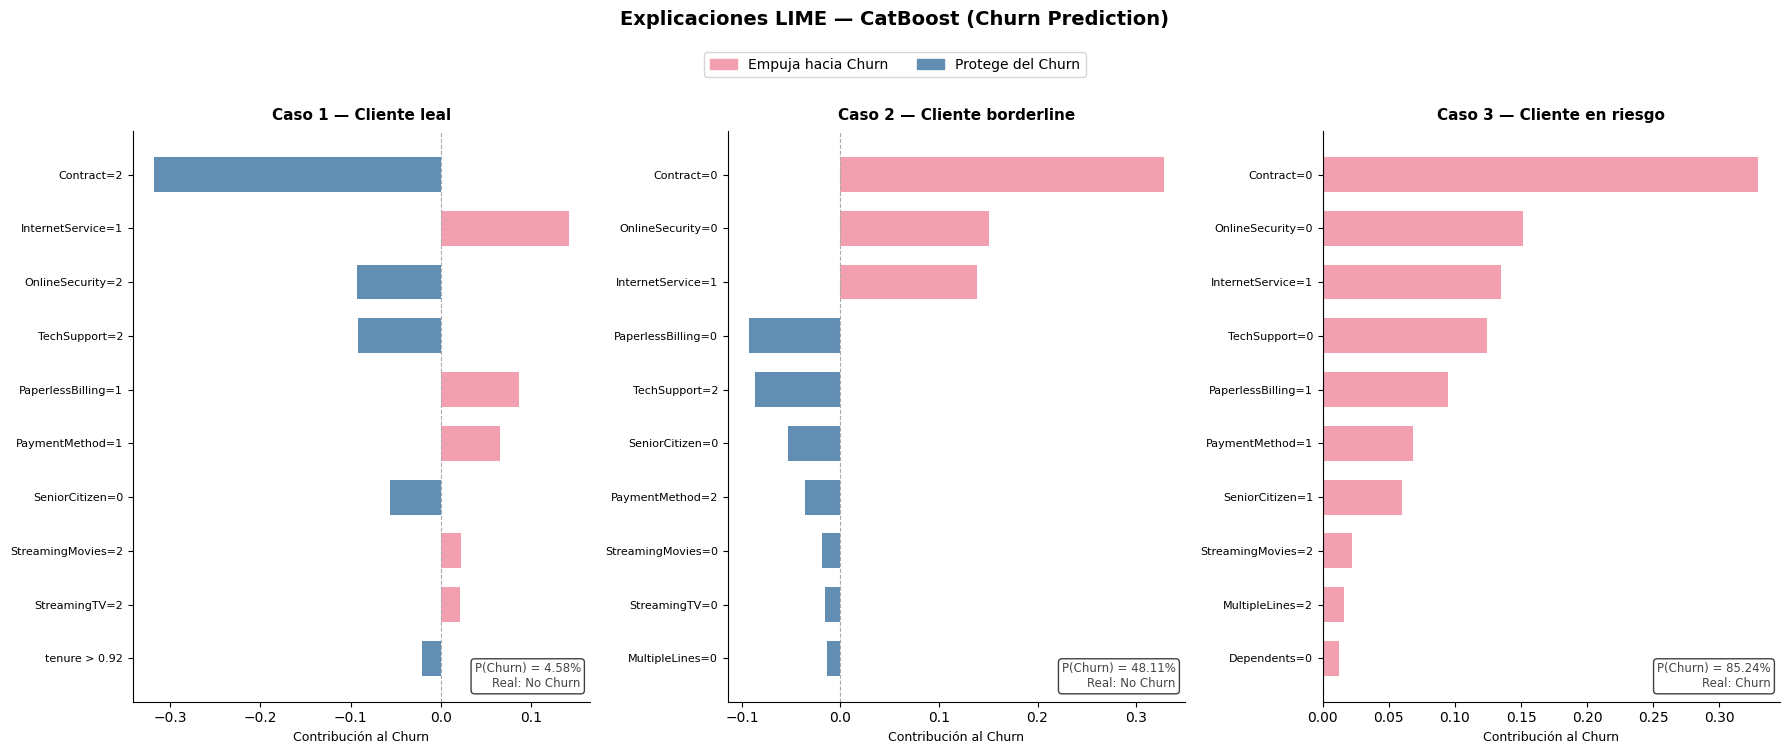

In [29]:
COLOR_CHURN   = "#F2A0B0"
COLOR_PROTECT = "#628EB3"

def plot_lime(idx, titulo, ax, n_features=10):
    instancia = X_test_lime[idx]

    exp = explainer.explain_instance(
        data_row     = instancia,
        predict_fn   = predict_fn,
        num_features = n_features,
        num_samples  = 5000,
        labels       = [0, 1],  
    )

    label_disponible = 1 if 1 in exp.local_exp else list(exp.local_exp.keys())[0]
    pesos   = exp.as_list(label=label_disponible)

    labels  = [f for f, _ in pesos]
    weights = [w for _, w in pesos]
    colors  = [COLOR_CHURN if w > 0 else COLOR_PROTECT for w in weights]

    orden   = np.argsort(np.abs(weights))
    labels  = [labels[i]  for i in orden]
    weights = [weights[i] for i in orden]
    colors  = [colors[i]  for i in orden]

    ax.barh(labels, weights, color=colors, edgecolor="none", height=0.65)
    ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Contribución al Churn", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

    real = "Churn" if y_test.iloc[idx] == 1 else "No Churn"
    ax.text(0.98, 0.02,
            f"P(Churn) = {y_prob[idx]:.2%}\nReal: {real}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (titulo, idx) in zip(axes, casos.items()):
    plot_lime(idx, titulo, ax)

patch_push    = mpatches.Patch(color=COLOR_CHURN,   label="Empuja hacia Churn")
patch_protect = mpatches.Patch(color=COLOR_PROTECT, label="Protege del Churn")
fig.legend(handles=[patch_push, patch_protect],
           loc="upper center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), framealpha=0.8)

fig.suptitle(
    f"Explicaciones LIME — {MODEL_NAME} (Churn Prediction)",
    fontsize=14, fontweight="bold", y=1.07
)
plt.tight_layout()
plt.savefig("../data/lime_explanations.png", dpi=150, bbox_inches="tight")
plt.show()


### ***Caso 1***

Este cliente presenta una probabilidad de abandono extremadamente baja. La variable de mayor peso protector es Contract=2, que corresponde a un contrato de dos años, lo cual es consistente con la evidencia global del modelo: los contratos de largo plazo son el factor de retención más sólido. Complementan esta protección OnlineSecurity=2 y TechSupport=2, indicando que el cliente tiene activos ambos servicios de soporte. En sentido contrario, InternetService=1 (Fiber optic) y PaperlessBilling=1 ejercen una leve presión hacia churn, lo que sugiere que incluso en clientes leales el servicio de fibra óptica está asociado históricamente con mayor rotación, aunque en este caso es ampliamente compensado por el tipo de contrato.

### ***Caso 2***

Este es el caso más interesante desde el punto de vista del negocio, ya que el modelo no logra clasificarlo con certeza. La variable Contract=0 (contrato mes a mes) es la que más empuja hacia churn, seguida de OnlineSecurity=0 y InternetService=1, lo cual configura un perfil de riesgo claro: cliente sin compromiso contractual, sin seguridad en línea y con fibra óptica. Sin embargo, variables como TechSupport=2, SeniorCitizen=0 y PaperlessBilling=0 actúan como factores moderadores que reducen la probabilidad de abandono, resultando en un balance casi perfecto entre ambas fuerzas. Este cliente es candidato prioritario para una campaña de retención proactiva, dado que una intervención oportuna podría inclinar la balanza hacia la permanencia.

### ***Caso 3***

Este caso representa el perfil de desertor más claro del análisis. Contract=0 domina ampliamente la explicación con la mayor contribución positiva al churn de los tres casos, reforzando que la ausencia de compromiso contractual es el predictor más crítico del modelo. A esto se suman OnlineSecurity=0, InternetService=1 y TechSupport=0, configurando un cliente con contrato mensual, fibra óptica y sin ningún servicio de soporte o seguridad activo. El único factor que ejerce una leve protección es StreamingTV=0, aunque su peso es marginal frente a las fuerzas que empujan al abandono. El modelo clasifica correctamente este caso, y la explicación LIME es coherente con la intuición de negocio: un cliente sin ataduras contractuales, sin servicios de valor agregado y con el servicio de mayor costo tiene todas las condiciones para desertar.

En conlusión, los tres casos confirman que Contract es la variable con mayor poder explicativo individual en CatBoost, lo cual es consistente con los resultados de feature importance del notebook anterior. OnlineSecurity e InternetService aparecen de forma recurrente como moduladores del riesgo, mientras que variables demográficas como SeniorCitizen tienen un papel secundario.